In [6]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import matplotlib.pyplot as plt

In [8]:
# Reading the dataset
df = pd.read_csv(
    "data_Hw3_new.csv",
    sep=";",
    parse_dates=["Date"],
    date_format=lambda x: pd.to_datetime(x, format="%m/%d/%y %H:%M")
)
df .head()

,Date,WE_O3,AE_O3,WE_NO2,AE_NO2,Temp,RelHum,RefSt_O3
0,6/4/23 0:00,455.58,451.83,449.58,445.33,21.47,69.58,54.0
1,6/4/23 1:00,452.92,452.75,448.75,446.25,21.17,71.98,64.0
2,6/4/23 2:00,453.50,452.58,444.92,447.00,21.03,71.65,56.0
3,6/4/23 3:00,450.75,452.25,437.58,446.50,21.10,70.75,43.0
4,6/4/23 4:00,448.58,451.50,433.33,445.50,20.79,69.68,34.0


In [10]:
# Separate the information from Captor from the true values
# Captor data
X = df .iloc[:, 1:-1]
# True values
y = df .iloc[:, -1]

In [12]:
# Number of samples to use for training, first 4 weeks (24*7*4)
n_train = 672

X_train = X.iloc[:n_train]
X_test  = X.iloc[n_train:]

y_train = y.iloc[:n_train]
y_test  = y.iloc[n_train:]


In [23]:
# Create the MLR model 
reg = LinearRegression().fit(X_train, y_train)
y_predicted_reg = reg.predict(X_test)

In [18]:
knr = KNeighborsRegressor(n_neighbors = 5, n_jobs=-1).fit(X_train, y_train)
y_predicted_KNR = knr.predict(X_test)

In [28]:
rfr = RandomForestRegressor(max_depth= 21, random_state=0).fit(X_train, y_train)
y_predicted_RF = rfr.predict(X_test)

In [44]:
r2_MLR = []
r2_KNN = []
r2_RF = []
first_day = 0
last_day = 24
for i in range (60):
    r2_MLR.append(r2_score(y_test[first_day:last_day], y_predicted_reg[first_day:last_day]))
    r2_KNN.append(r2_score(y_test[first_day:last_day], y_predicted_KNR[first_day:last_day]))
    r2_RF.append(r2_score(y_test[first_day:last_day], y_predicted_RF[first_day:last_day]))
    first_day = first_day + 24
    last_day = last_day + 24
    


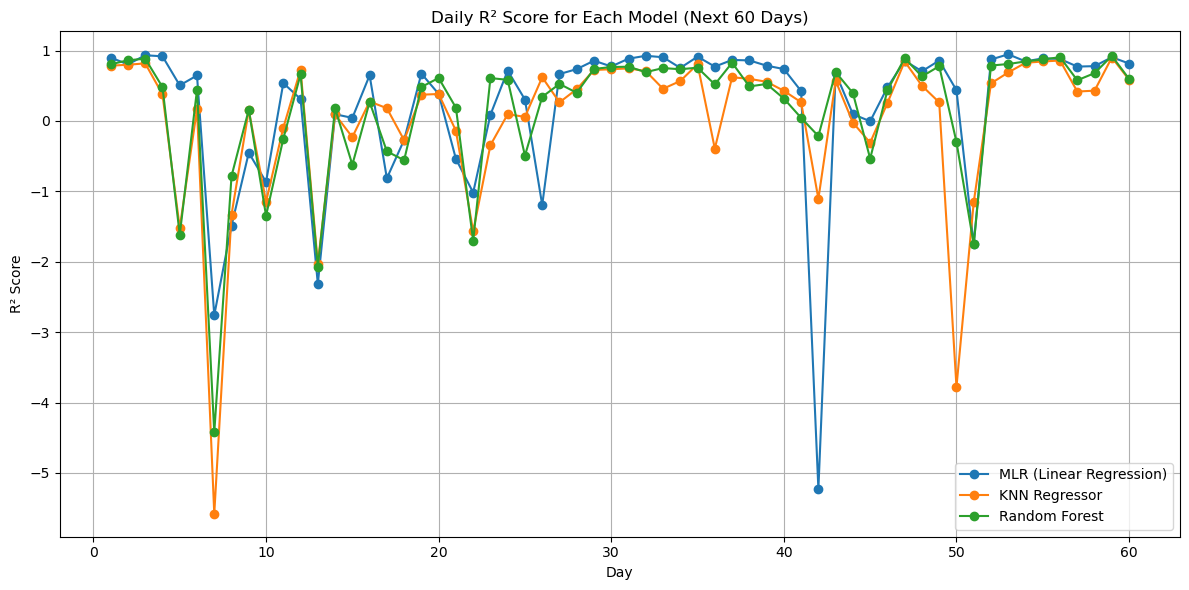

In [45]:
days = np.arange(1, len(r2_MLR) + 1)

plt.figure(figsize=(12,6))

plt.plot(days, r2_MLR, marker='o', label='MLR (Linear Regression)')
plt.plot(days, r2_KNN, marker='o', label='KNN Regressor')
plt.plot(days, r2_RF, marker='o', label='Random Forest')

plt.xlabel('Day')
plt.ylabel('R² Score')
plt.title('Daily R² Score for Each Model (Next 60 Days)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
r2_MLR = []
r2_KNN = []
r2_RF = []
first_day = 0
last_day = 48
for i in range (30):
    r2_MLR.append(r2_score(y_test[first_day:last_day], y_predicted_reg[first_day:last_day]))
    r2_KNN.append(r2_score(y_test[first_day:last_day], y_predicted_KNR[first_day:last_day]))
    r2_RF.append(r2_score(y_test[first_day:last_day], y_predicted_RF[first_day:last_day]))
    first_day = first_day + 48
    last_day = last_day + 48
    


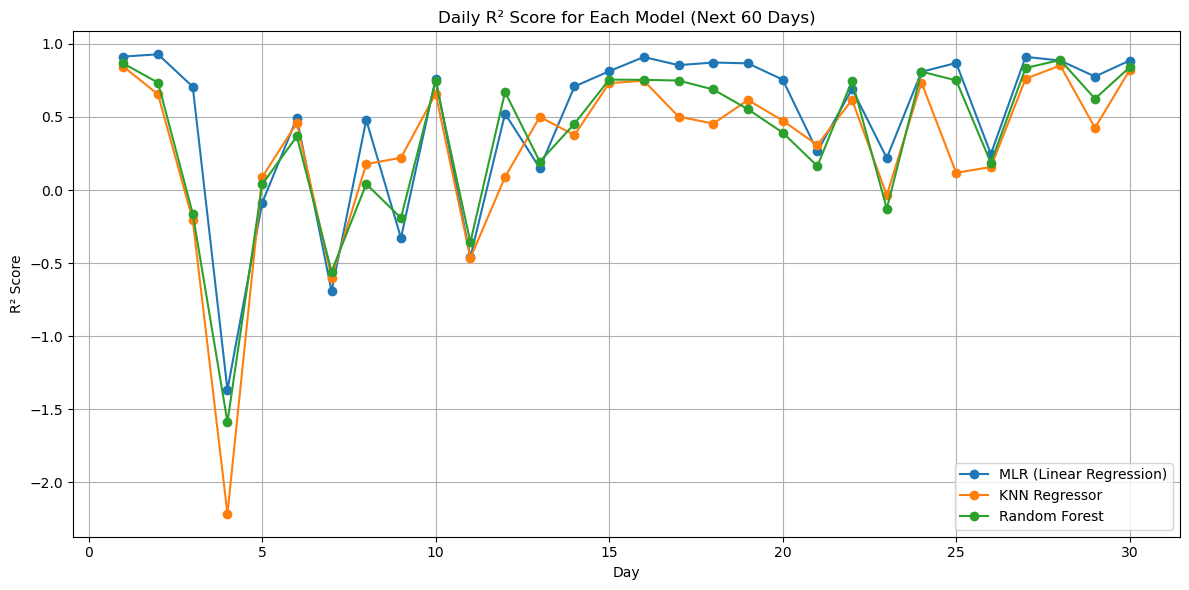

In [48]:
days = np.arange(1, len(r2_MLR) + 1)

plt.figure(figsize=(12,6))

plt.plot(days, r2_MLR, marker='o', label='MLR (Linear Regression)')
plt.plot(days, r2_KNN, marker='o', label='KNN Regressor')
plt.plot(days, r2_RF, marker='o', label='Random Forest')

plt.xlabel('Day')
plt.ylabel('R² Score')
plt.title('Daily R² Score for Each Model (Next 60 Days)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
